# Demo 7 — E/I sheet driven by a moving wave (2-D)

A two-population excitatory/inhibitory sheet driven by a **time-varying** drifting
grating (`inputs.traveling_wave`), integrated with `simulate_sequence`. We watch
the excitatory and inhibitory populations track the moving stimulus.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in this repository folder (itself named
# "cortical_rate_model"), so we add the PARENT directory to the path.
import sys, pathlib
_cwd = pathlib.Path.cwd()
_parent = _cwd.parent if _cwd.name == "cortical_rate_model" else _cwd
sys.path.insert(0, str(_parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

In [3]:
sheet = Layout((24, 24), periodic=True)
ei = build_ei(sheet, sigma_ee=2.0, sigma_ei=5.0, sigma_ie=2.0, sigma_ii=5.0,
              spectral_radius=0.9)
print(ei, "-> 2N =", ei.num_units)

# moving grating fed to the excitatory population, frame by frame
n_steps = 120
wave = inputs.traveling_wave(sheet, n_steps=n_steps, wavelength=8.0,
                             orientation=np.pi / 4, n_cycles=2)
wave_ei = np.stack([inputs.to_ei_input(exc_input=frame, num_units=sheet.num_units)
                    for frame in wave])           # (time, 2N)
print("wave input sequence shape:", wave_ei.shape)

EIRateNetwork(num_units=1152, nonlinearity='rectification', integrator='forward_euler', dt=0.1) -> 2N = 1152
wave input sequence shape: (120, 1152)


## The moving stimulus

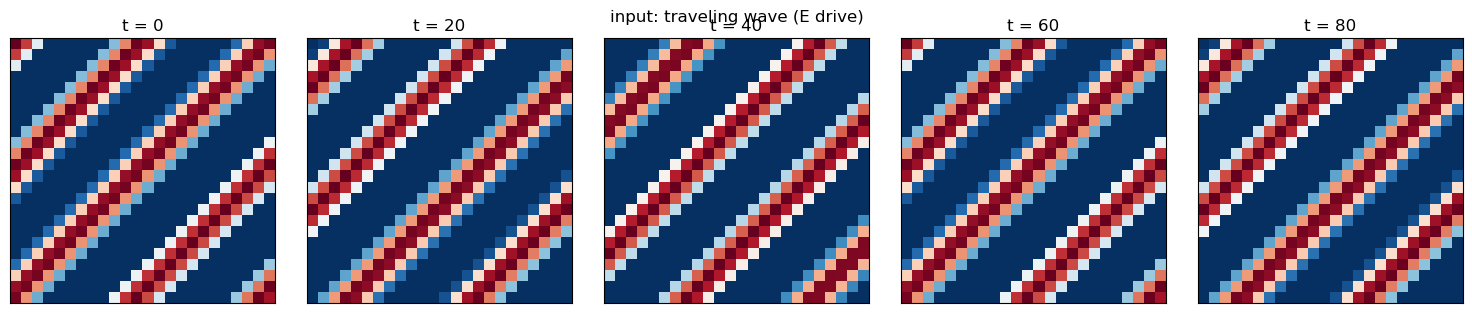

In [4]:
fig = plotting.plot_activity_snapshots(wave, sheet, times=[0, 20, 40, 60, 80],
                                       symmetric=False)
fig.suptitle("input: traveling wave (E drive)", y=1.03); plt.show()

## Excitatory response following the wave

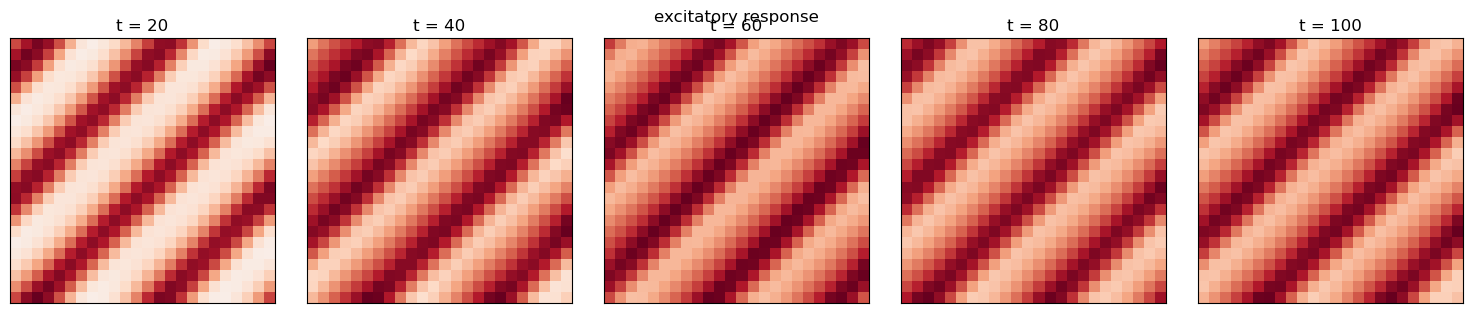

In [5]:
traj = ei.simulate_sequence(wave_ei, record="all").numpy()   # (time, 2N)
traj_exc = traj[:, ei.meta["exc_slice"]]
traj_inh = traj[:, ei.meta["inh_slice"]]

fig = plotting.plot_activity_snapshots(traj_exc, sheet, times=[20, 40, 60, 80, 100])
fig.suptitle("excitatory response", y=1.03); plt.show()

## Inhibitory response

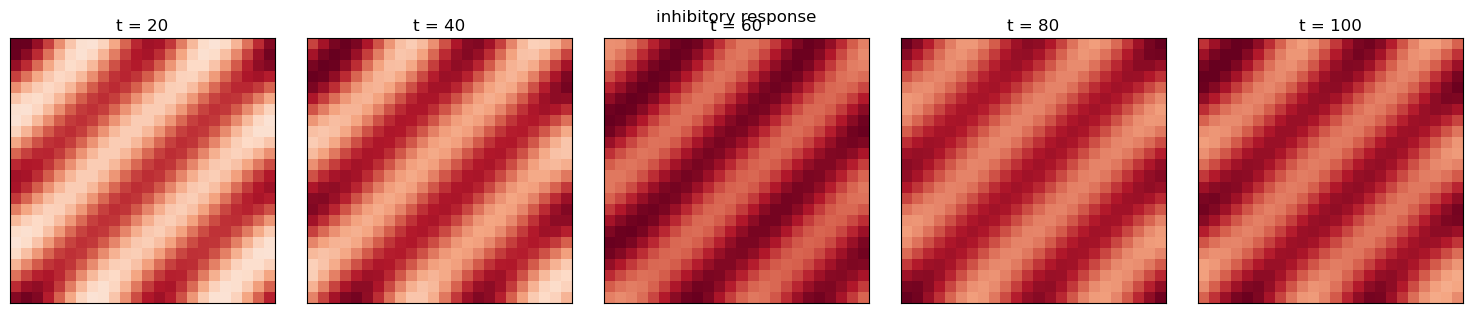

In [6]:
fig = plotting.plot_activity_snapshots(traj_inh, sheet, times=[20, 40, 60, 80, 100])
fig.suptitle("inhibitory response", y=1.03); plt.show()

## Activity at one site over time

The rate at a fixed unit oscillates as the wave sweeps past it.

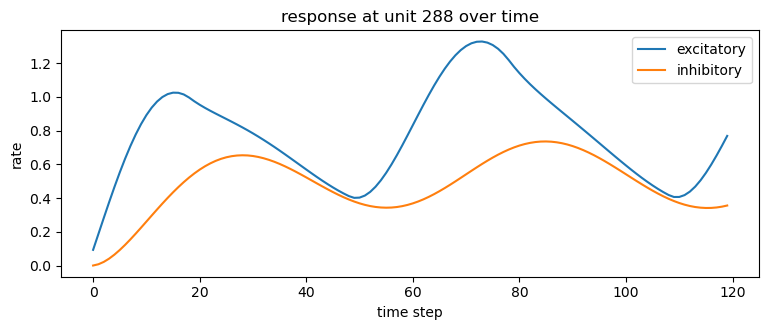

In [7]:
unit = sheet.num_units // 2
plt.figure(figsize=(9, 3.2))
plt.plot(traj_exc[:, unit], label="excitatory")
plt.plot(traj_inh[:, unit], label="inhibitory")
plt.xlabel("time step"); plt.ylabel("rate")
plt.title(f"response at unit {unit} over time"); plt.legend(); plt.show()